# STA272 Lab #5

## Purpose of Lab

Welcome to your fifth weekly tutorial lab!

You are encouraged to refer to lecture content and liberally use course resources.

## Logistics

Due date: The homework is due **11:59pm on Thursday, February 5, 2026.**

You will submit your homework on [MarkUs](https://markus.teach.cs.toronto.edu/markus/).

1. Download this file (`STA272_lab4_student.ipynb`) from JupyterHub. (See [our JupyterHub Guide](../guides/jupyterhub_guide.ipynb) for detailed instructions.)
2. Submit this file to MarkUs under the hw4 assignment. (See [our MarkUs Guide](../guides/markus_guide.ipynb) for detailed instructions.)

## Task #1

Data from the National; Health and Nutrition Examination Survey Epidemiologic Followup Study (NHEFS) is in the csv file `nhefs9282.csv`.  Store this file in a pandas dataframe called `nhefs_df`.


In [ ]:
# Place your answer for Task #1 in this cell 

In [1]:
# Answer cell

import pandas as pd

nhefs_df = pd.read_csv('nhefs9282.csv')

nhefs_df.head()

,HANESEQ,wt1982,wt1992,smoke1982,smoke1992,sex,genhealth1982,hyperhb1982,cancer1982,cough1982,...,age1992,age1982,marital1992,deathage1992,height1982,weight1982,weight1992,wtgain,qsmoke,incomeclass
0,1,150.0,175,1.0,NaN,2.0,3.0,NaN,2.0,2.0,...,60,50.0,3.0,NaN,164.3,150.0,175.0,25.0,NaN,4.0
1,2,179.0,170,2.0,NaN,1.0,3.0,NaN,2.0,2.0,...,82,72.0,1.0,NaN,168.7,179.0,170.0,-9.0,NaN,4.0
2,8,141.0,140,1.0,NaN,2.0,3.0,2.0,2.0,1.0,...,56,46.0,1.0,NaN,163.9,141.0,140.0,-1.0,NaN,NaN
3,16,130.0,131,NaN,NaN,2.0,1.0,2.0,2.0,2.0,...,85,75.0,2.0,NaN,156.4,130.0,131.0,1.0,NaN,NaN
4,17,167.0,180,NaN,NaN,1.0,3.0,2.0,2.0,2.0,...,67,57.0,1.0,NaN,167.8,167.0,180.0,13.0,NaN,1.0


In the next few tasks you will build a classification tree to predict subjects that quit smoking between 1982 and 1992. 

The file `nhefs_codebook.md` contains a data dictionary.  Identify the variables that measure

- quitting smoking in 1992
- general health in 1982
- heart attack in 1982
- drinking coffee in 1982


## Task #2

Create a pandas dataframe from `nhefs_df` called `tree_df` that only contains these four variables with **no missing values** in the dataframe.  To remove missing values from the dataframe use the pandas method `dropna()`.


In [35]:
#Place your answer for Task #2 in this cell

# examine the shape of tree_df
tree_df.shape

In [27]:
# Answer cell

tree_cols = ['qsmoke', 'genhealth1982', 'heartattack1982', 'drinkcoff1982']

tree_df = nhefs_df[tree_cols].dropna()

In [28]:
tree_df.shape

(279, 4)

## Task #3

Create test and training samples using `train_test_split` from `sklearn.model_selection` where the test size is 25% of the data and set the `random_state` parameter to 30.

The training and test features should be stored as `X_train` and `X_test`.  The training and test outcomes should be stored as `y_train` and `y_test`. 

In [29]:
#Place your answer for Task #3 in this cell


In [31]:
# Answer cell

from sklearn.model_selection import train_test_split

X = tree_df[tree_cols[1:4]]

y = tree_df[tree_cols[0]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=30)


## Task #4

Use `DecisionTreeClassifier` from `sklearn.tree` to fit the tree on the training data from the previous task. Store the tree in `qsmoke_dt`.

The following parameters in `DecisionTreeClassifier` should be set: 

- `'entropy'` criterion to measure node impurity
- tree of depth 3
- minimum number of samples to split on is 10
- minimum number of samples in a leaf is 10

In [36]:
#Place your answer for Task #4 in this cell



In [60]:
# Answer cell

from sklearn.tree import DecisionTreeClassifier

qsmoke_dt = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_split=10, min_samples_leaf=10,min_impurity_decrease=0.01)

qsmoke_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

## Task #5

Plot `qsmoke_dt` using `plot_tree`. Use the original variable names to set `feature_names`. `class_names` should be set to `Quit` and `Continue`.  Fill in `...` in the code below.  

**NB: The last line `treeplt = ax` in the code cell is used for autotesting so don't delete it.**

In [ ]:
#Place your answer for Task #5 in this cell

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

plot_tree(..., 
          feature_names= ...,
          class_names=...,
          filled=True, 
          rounded=True,
          proportion=False,
          fontsize=10)

# do not delete
treeplt = ax

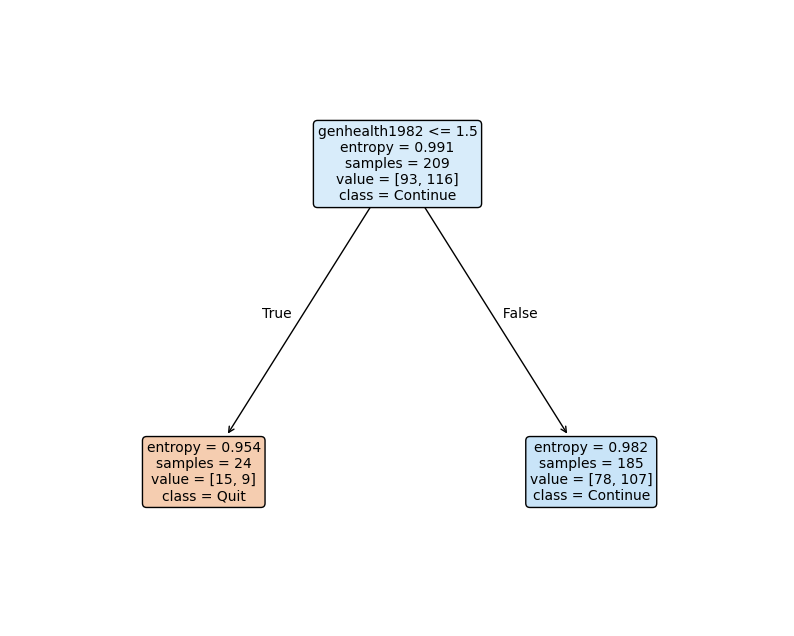

In [67]:
#Answer cell

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

plot_tree(qsmoke_dt, 
          feature_names= tree_cols,
          class_names=['Quit', 'Continue'],
          filled=True, 
          rounded=True,
          proportion=False,
          fontsize=10)

# do not delete
treeplt = ax

## Task #6

Use the features in the test set `X_test` to compute the predicted classes using `qsmoke_dt` and store the values in `y_pred`.  Then compute the confusion matrix using `confusion_matrix` and classification report using `classification_report` from `sklearn.metrics`.  Store the confusion matrix in a variable called `cmatrix` and the classification report in a variable called `creport`.

In [ ]:
#Place your answer for Task #6 in this cell


y_pred = ...

cmatrix = ...

creport = ...

print(cmatrix)
print(creport)

In [78]:
#Answer
from sklearn.metrics import confusion_matrix, classification_report

y_pred = qsmoke_dt.predict(X_test)

cmatrix = confusion_matrix(y_test, y_pred)

creport = classification_report(y_test, y_pred)

print(cmatrix)
print(creport)

[[ 3 24]
 [ 4 39]]
              precision    recall  f1-score   support

         1.0       0.43      0.11      0.18        27
         2.0       0.62      0.91      0.74        43

    accuracy                           0.60        70
   macro avg       0.52      0.51      0.46        70
weighted avg       0.55      0.60      0.52        70

